In [39]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
def f(x):
    return 3*x**2 -4*x + 5

In [41]:
f(3.0)

20.0

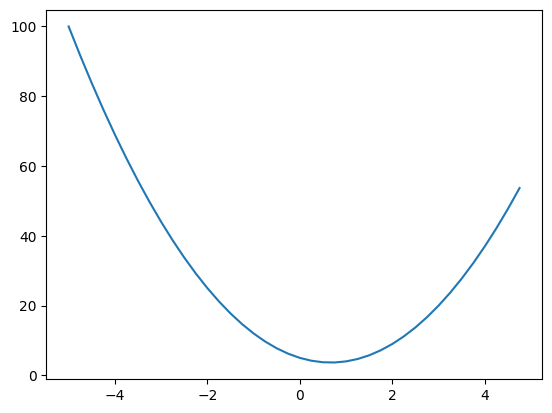

In [42]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

The derivative ... bump x by a small amount h and see how f(x) responds. What is the slope of a line between x and x+h?
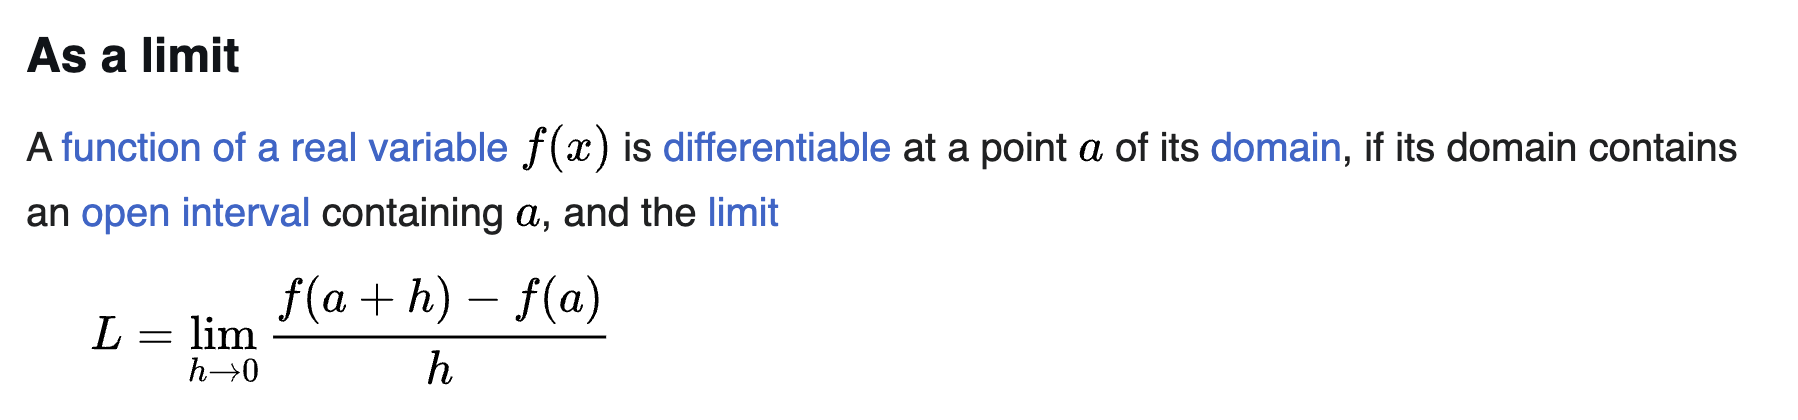

In [43]:
h = .0000001
x = 2/3
(f(x + h) - f(x))/h

2.9753977059954195e-07

In [44]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


now work on the derivative of d wrt a. Set h to a small number. calculate a first value for d. calculate a second value for d, bumped a little by h. So we can get the secant line between d1 and d2. If I were to shrink h, then the (d1 - d2)/h term would move to the slope of the tangent line (the derivative!) at a of d wrt a

In [45]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)

print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


I understand the basic concept behind and how to get a derivative. Now we need to add some complexity to be able to use this concept with neural networks. Build the Value data structure.

Value will allow the creation of a network of expressions with each math operation being able to point "back" to its constituent pieces

In [46]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):#_children is an empty tuple. The underscore is a convention ... "internal"
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None #an inline function that returns nothing
        self._prev = set(_children) #the precursors for this value in the expression graph - the inputs to this operation
        self._op = _op #the operation to be performed
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to be able to add just a number, wrap the number passed in into a Value object
        out = Value(self.data + other.data, (self, other), '+')#illustrates attaching the parameters as what comes before in the expression graph
        
        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            #out is the value housing the sum. out.grad is the influence that sum, the result of this addition has on the final node (L, in our example here)
            #self and other are inputs that result in out
            #self.grad is the influence that self has on the final node
            #other.grad is the influence that other has on the final node
            #if I know the influence out has on the final node and I know the influence dself has on dout then I know the influence dself has on the final node, or ....
            #dL/dself = dout/dself * dL/dout
            #dL/dout = out.grad
            #dout/dself = d(self + other)/dself = 1.0, becuause the derivative of 1 self + other (other is the constant) equals 1.0
            #So, self.grad = dL/dself = dout/dself * dL/dout = 1.0 * out.grad
            self.grad += 1.0 * out.grad #out.grad is the influence out has on the final node in the graph
            other.grad += 1.0 * out.grad #similarly ...

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to be able to add just a number, wrap the number passed in into a Value object
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            self.grad += other.data * out.grad #out.grad is the influence out has on the final node in the graph
            #dL/dself = dL/dout * dout/dself = out.grad * other.data because the derivative of a '*' node is just the other operand per explanations below
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh') #only one child, so (self, ) is Python for a tuple with only one element

        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            #dL/dself = dL/dout * dout/dself = dL/dout * dout/dx ~= dL/dout * dt/dx = dL/dout * (1 - t**2) = out.grad * (1 - t**2)
            self.grad += out.grad * (1 - t**2)
        
        out._backward = _backward
        return out
    
    def backward(self):
        topo = [] #builds a topological sort of the nodes, starting at the 'o' node but putting their .data values in left to right order
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):# call backward() right to left on our topological sort
            node._backward()
    
# a = Value(2.0, label='a')
# b = Value(-3.0, label='b')
# c = Value(10, label='c')
# e = a*b; e.label = 'e'
# #a + b
# #a * b
# d = e + c; d.label = 'd'
# f = Value(-2.0, label='f')
# L = d * f; L.label = 'L'
# print(f"L label: {L.label}")
# L
# #print(f"children of d: {d._prev}")
# #print(f"op of d: {d._op}")
# #d = a*b + c
# ##d._prev
# #d._op

In [47]:
a = Value(2.0)
a + 1
a * 14

2 * a

Value(data=4.0)

In [48]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    #dot.node(name = uid, label = "{ %s | data %.4f}" % (n.label, n.data), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [49]:
#draw_dot(d)

In [50]:
from IPython.display import display, HTML

display(HTML("""
<style>
    .cell-output-ipywidget-background {
        background-color: transparent !important;
    }
    .jp-OutputArea-output {
        overflow-x: auto !important;
        display: block !important;
    }
</style>
"""))

In [51]:
# L.grad = 1.00
# d.grad = -2.00
# f.grad = 4.00
# c.grad = -2.0
# e.grad = -2.0
# a.grad = 6.0
# b.grad = -4.0
#each of the above gives how much L is influenced when the variable is bumped. So, a has the biggest impact

In [52]:
#draw_dot(L)

So far .... we can take math operations, made up of Values and operations and build an expression graph. The graphviz diagram immediately above. And that also gives us the "forward pass" - what inputs and operations, moving left to right, yield our final value

Next, figure out backpropagation ... what are the gradients, or what effect does each input have, on L? For example, the gradient of c wrt L is "How much is L affected when I wiggle c?"

If I know the impact that c has on d and if I l know the impact that d has on L, **then I know the impact that c has on L**. A chain ...
...>> The Chain Rule of Calculus
[The Chain Rule of Calculus](https://en.wikipedia.org/wiki/Chain_rule)

d = 1*e +1*c
dd/dc = 1
dd/de = 1

dL/dc = dL/dd * dd/dc = -2 * 1 = -2.0
dL/de = dL/dd * dd/de = -2 * 1 = -2.0

e = a * b
de / da = b = -3.0
Similarly, de / db = a = 2.0

So now, what is a's influence on L?
dL / da = (dL / de) * (de / da) = -2.0 * -3.0 = 6.0 --> a.grad. "grad" implies the gradient of a with respect to L --> What impact does a have on L?
and
dL / db = (dL / de) * (de / db) = -2.0 * 2.0 = -4.0 --> b.grad 

**Backpropagation is just the recursive application of the chain rule from the end node L back to the start nodes, a & b. 
We ask, "How does d influence L?" and "How do e and c influence d?" and "How do a and b influence e?"
Each of those "How do's" is the derivative. We multiply each of those local derivative together to get the influence of a upon L.

dL / da = (de / da) * (dd / de) * (dL / dd) = -3.0 * 1.0 * -2.0 = 6.0
dL / db = (de / db) * (dd / de) * (dL / dd) = 2.0 * 1.0 * -2.0 = -4.0


L = d * f is my f(x)
What is DL/dd, or what is the derivative of L wrt d?
we are bumping h by a small amount

Use the definition:
DL/dd = the limit as h --> 0 of ((d+h)*f-d*f)/h
(d*f + h*f - d*f)/h
(h*f)/h
f

DL/dd d*f = f

So, ^^^^ tells me how d affects L - d.grad means, "what is d's affect on the next downstream node --> L
And, similarly, I also know how f affects L

In [53]:
#"move" in the gradient direction by some small amount for all the inputs that we have control over
# a.data += 0.01 * a.grad
# b.data += 0.01 * b.grad
# c.data += 0.01 * c.grad
# f.data += 0.01 * f.grad

# #rerun the forward pass (the intermediate and final calculation, using our altered "leaf" input values)
# e = a*b
# d = e + c
# L = d * f

# print(L.data)

In [54]:
#this is just a play function for manual verification of derivative calculatons
# def lol():
#     h = .0001
    
#     a = Value(2.0, label='a')
#     b = Value(-3.0, label='b')
#     c = Value(10, label='c')
#     e = a*b; e.label = 'e'
#     #a + b
#     #a * b
#     d = e + c; d.label = 'd'
#     f = Value(-2.0, label='f')
#     L = d * f; L.label = 'L' #L represents our fake,simple, loss function
#     L1 = L.data

#     a = Value(2.0, label='a')
#     #a.data += h
#     b = Value(-3.0, label='b')
#     b.data +=h
#     c = Value(10, label='c')
#     #c.data += h #bump c by a small amount
#     e = a*b; e.label = 'e'
#     #e.data += h #bump e by a small amount
#     #a + b
#     #a * b
#     d = e + c; d.label = 'd'
#     f = Value(-2.0, label='f')
#     L = d * f; L.label = 'L'
#     L2 = L.data
#     print((L2-L1)/h) #what is derivative? How much did bumping the chosen variable affect L?

# lol()


In [55]:
#plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();#tanh is an activation function that "squishes" the output to plateau at 1 and -1

In [56]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2' #doing the dot product
n = x1w1x2w2 + b; n.label = 'n' # "sum" of errors
o = n.tanh(); o.label = 'o' #activation function applied

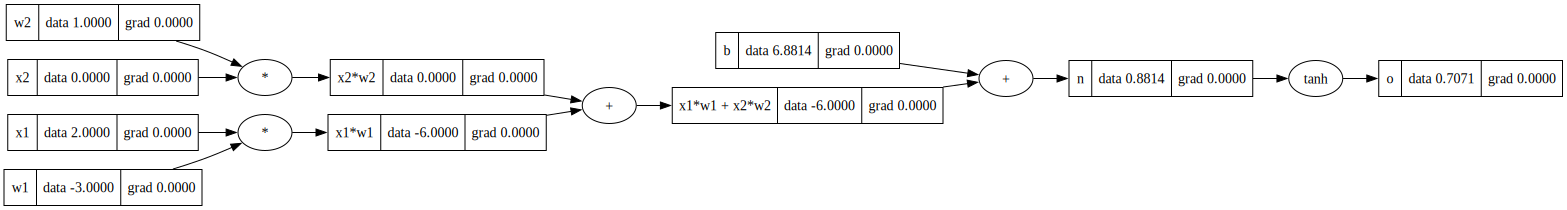

In [57]:
draw_dot(o)

In [58]:
o.backward() #THIS IS THE REAL/FINAL FUNCTION CALL TO USE

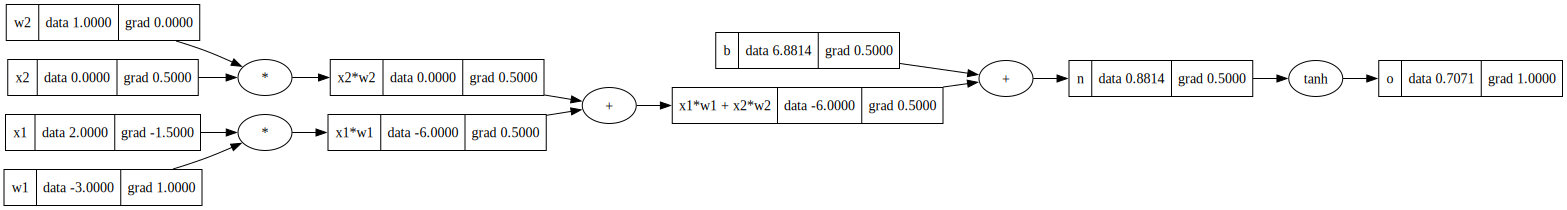

In [59]:
draw_dot(o) #THIS IS THE REAL/FINAL FUNCTION CALL TO USE

In [60]:
# o.grad = 1.0

# topo = [] #builds a topological sort of the nodes, starting at the 'o' node but putting their .data values in left to right order
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)

# for node in reversed(topo):# call backward() right to left on our topological sort
#   node._backward()

In [61]:
# topo = [] #builds a topological sort of the nodes, starting at the 'o' node but putting their .data values in left to right order
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)
# topo

In [62]:
# #call backward() in the right order 
# o.grad = 1.0

In [63]:

#o._backward()

In [64]:
#n._backward()

In [65]:
#b._backward()

In [66]:
#x1w1x2w2._backward()

In [67]:
# x1w1._backward()
# x2w2._backward()

In [68]:
# draw_dot(o)

In [69]:
# x1w1.grad = 0.5
# x2w2.grad = 0.5

In [70]:
#What is the influence of x2 on o?
#x2w2 = x2 * w2
#dx2w2 / dx2 = w2
#do/dx2 = (do/dx2w2) * (dx2w2 / dx2) = x2w2.grad * w2 = 0.5 * 1.0 = 0.5

#What is the influence of x1 on o?
#x1w1 = x2 * w1
#dx1w1 / dx1 = w1
#do/dx1 = (do/dx1w1) * (dx1w1 / dx1) = x1w1.grad * w1 = 0.5 * -3.0 = -1.5
# x1.grad = x1w1.grad * w1.data
# w1.grad = x1w1.grad * x1.data

# x2.grad = x2w2.grad * w2.data
# w2.grad = x2w2.grad * x2.data    

In [71]:
#n = b + x1w1x2w2
#dn/db = 1
#dn/dx1w1x2w2 = 1

#do/db = b.grad = do/dn * dn/db = .5 * 1 = .5
#do/dx1w1x2w2 = x1w1x2w2.grad = do/dn * dn/dx1w1x2w2 = .5 * 1 = .5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5

In [72]:
# o = tanh(n)
#do/dn = 1 - tanh(n)**2 = 1 - o**2 ... the local derivative at the tanh() node wrt o, which is n.grad
#n.grad = o.data ** 2 = 0.7071 ** 2 = 0.5
#n.grad = 0.5 #I know that n.grad is .5, or do/dn = .5


In [73]:
#o.grad = 1.0 #do / do

In [74]:
#draw_dot(o)

In [75]:
#demonstrating the hidden "bug"
# a = Value(3.0, label = 'a')
# b = a + a; b.label = 'b'
# b.backward()
# draw_dot(b)

#after the '+=' fix, since a appears twice in a + a, then we pick up 1.0 twice and so a.grad = 2.0

In [76]:
#another more complex demonstration of the problem ...
# a = Value(-2.0, label = 'a')
# b = Value(3.0, label = 'b')
# d = a * b; d.label = 'd'
# e = a + b; e.label = 'e'
# f = d * e; f.label = 'f'

# f.backward()

# draw_dot(f)

#in the result of draw_dot()
#f.grad = 1.0, by definition
#a.grad = df/da
#df/da = df/de * de/da
#df/de = e.grad = -6.0
#de/da = d(a + b)/da = 1.0
#so, df/da (for the first usage or a to compute e) is -6.0 * 1/0 = -6.0

#doing the same for the usage of a to compute d ....
#dd/da = d(a * b)/da = b = 3.0
#and since a is used twice, once to compute e and once to compute d, there are two contributions to a.grad, one from the sum and one from the mult
#and we add those up, to accumulate them, so df/da = a.grad = -6.0 + 3.0 = -3.0
#similarly, b.grad = -8.0
